In [1]:
import pathlib
import numpy as np

In [2]:
!mkdir -p /home/jovyan/data/dataset_dollarstreet

In [3]:
!wget -nc -P /home/jovyan/data/dataset_dollarstreet https://zenodo.org/records/10970014/files/test_images.npy
!wget -nc -P /home/jovyan/data/dataset_dollarstreet https://zenodo.org/records/10970014/files/test_labels.npy
!wget -nc -P /home/jovyan/data/dataset_dollarstreet https://zenodo.org/records/10970014/files/train_images.npy
!wget -nc -P /home/jovyan/data/dataset_dollarstreet https://zenodo.org/records/10970014/files/train_labels.npy

File ‘/home/jovyan/data/dataset_dollarstreet/test_images.npy’ already there; not retrieving.

File ‘/home/jovyan/data/dataset_dollarstreet/test_labels.npy’ already there; not retrieving.

File ‘/home/jovyan/data/dataset_dollarstreet/train_images.npy’ already there; not retrieving.

File ‘/home/jovyan/data/dataset_dollarstreet/train_labels.npy’ already there; not retrieving.



In [4]:
DATA_FOLDER = pathlib.Path('/home/jovyan/data/dataset_dollarstreet') # change to location where you stored the data
train_images = np.load(DATA_FOLDER / 'train_images.npy')
val_images = np.load(DATA_FOLDER / 'test_images.npy')
train_labels = np.load(DATA_FOLDER / 'train_labels.npy')
val_labels = np.load(DATA_FOLDER / 'test_labels.npy')

In [5]:
train_images.shape


(878, 64, 64, 3)

In [6]:
train_images.min(), train_images.max()


(0, 255)

In [7]:
train_labels.shape


(878,)

In [8]:
train_labels.min(), train_labels.max()


(0, 9)

In [9]:
train_images = train_images / 255.0
val_images = val_images / 255.0

In [10]:
width, height = (64, 64)
n_hidden_neurons = 100
n_bias = 100
n_input_items = width * height * 3
n_parameters = (n_input_items * n_hidden_neurons) + n_bias
n_parameters

1228900

In [11]:
from tensorflow import keras
keras.utils.set_random_seed(2)


inputs = keras.Input(shape=(n_input_items,))
outputs = keras.layers.Dense(100)(inputs)
model = keras.models.Model(inputs=inputs, outputs=outputs)
model.summary()

I0000 00:00:1777745125.802891     567 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777745125.861901     567 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777745127.516829     567 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
E0000 00:00:1777745128.453669     567 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │     1,228,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,228,900 (4.69 MB)

 Trainable params: 1,228,900 (4.69 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:


inputs = keras.Input(shape=train_images.shape[1:])
x = keras.layers.Conv2D(50, (3, 3), activation='relu')(inputs)
x = keras.layers.Conv2D(50, (3, 3), activation='relu')(x)
x = keras.layers.Flatten()(x)
outputs = keras.layers.Dense(10)(x)

model = keras.Model(inputs=inputs, outputs=outputs, name="dollar_street_model_small")

model.summary()

Model: "dollar_street_model_small"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 62, 62, 50)     │         1,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 60, 60, 50)     │        22,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 180000)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │     1,800,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,823,960 (6.96 MB)

 Trainable params: 1,823,960 (6.96 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
def create_nn(input_shape):
    inputs = keras.Input(shape=input_shape)
    x = keras.layers.Conv2D(50, (3, 3), activation='relu')(inputs)
    x = keras.layers.MaxPooling2D((2, 2))(x) # a new maxpooling layer
    x = keras.layers.Conv2D(50, (3, 3), activation='relu')(x)
    x = keras.layers.MaxPooling2D((2, 2))(x) # a new maxpooling layer (same as maxpool)
    x = keras.layers.Flatten()(x)
    x = keras.layers.Dense(50, activation='relu')(x) # a new Dense layer
    outputs = keras.layers.Dense(10)(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="dollar_street_model")
    return model

model = create_nn(input_shape=train_images.shape[1:])
model.summary()

Model: "dollar_street_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 62, 62, 50)     │         1,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 29, 29, 50)     │        22,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9800)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │       490,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 514,510 (1.96 MB)

 Trainable params: 514,510 (1.96 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
def compile_model(model):
    model.compile(optimizer='adam',
                  loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                  metrics=['accuracy'])
compile_model(model)

In [15]:
history = model.fit(train_images, train_labels, epochs=5,
                    validation_data=(val_images, val_labels))

Epoch 1/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 13s 420ms/step - accuracy: 0.1082 - loss: 2.3092 - val_accuracy: 0.1297 - val_loss: 2.2813
Epoch 2/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 11s 408ms/step - accuracy: 0.1731 - loss: 2.2539 - val_accuracy: 0.2082 - val_loss: 2.2147
Epoch 3/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 11s 396ms/step - accuracy: 0.2597 - loss: 2.0984 - val_accuracy: 0.3174 - val_loss: 2.0806
Epoch 4/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 11s 404ms/step - accuracy: 0.3610 - loss: 1.8474 - val_accuracy: 0.2662 - val_loss: 2.0662
Epoch 5/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 11s 374ms/step - accuracy: 0.4556 - loss: 1.5959 - val_accuracy: 0.2662 - val_loss: 2.1440


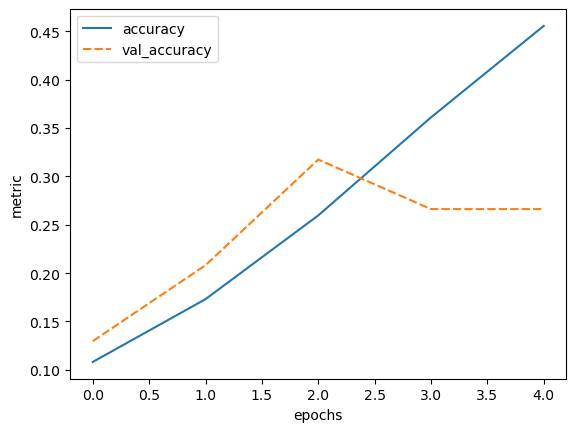

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def plot_history(history, metrics):
    """
    Plot the training history

    Args:
        history (keras History object that is returned by model.fit())
        metrics(str, list): Metric or a list of metrics to plot
    """
    history_df = pd.DataFrame.from_dict(history.history)
    sns.lineplot(data=history_df[metrics])
    plt.xlabel("epochs")
    plt.ylabel("metric")


plot_history(history, ['accuracy', 'val_accuracy'])

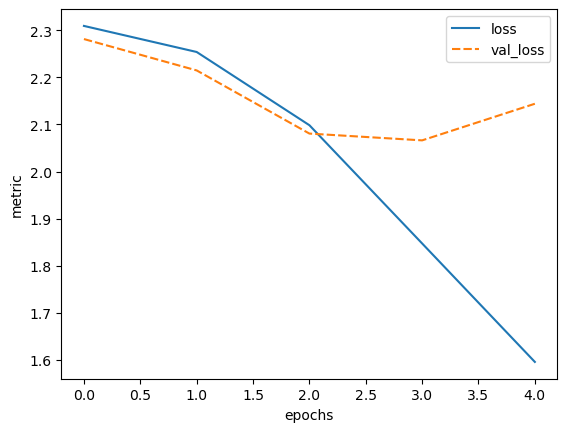

In [17]:
plot_history(history, ['loss', 'val_loss'])


In [18]:
def create_dense_model():
    inputs = keras.Input(shape=train_images.shape[1:])
    x = keras.layers.Flatten()(inputs)
    x = keras.layers.Dense(50, activation='relu')(x)
    x = keras.layers.Dense(50, activation='relu')(x)
    outputs = keras.layers.Dense(10)(x)
    return keras.models.Model(inputs=inputs, outputs=outputs,
                              name='dense_model')

dense_model = create_dense_model()
dense_model.summary()

Model: "dense_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 50)             │       614,450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 617,510 (2.36 MB)

 Trainable params: 617,510 (2.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.1196 - loss: 2.5585 - val_accuracy: 0.1604 - val_loss: 2.2559
Epoch 2/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.1390 - loss: 2.3124 - val_accuracy: 0.1297 - val_loss: 2.3061
Epoch 3/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.0934 - loss: 2.2959 - val_accuracy: 0.1092 - val_loss: 2.3024
Epoch 4/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.1173 - loss: 2.2871 - val_accuracy: 0.0990 - val_loss: 2.3015
Epoch 5/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.1276 - loss: 2.2751 - val_accuracy: 0.1468 - val_loss: 2.2943
Epoch 6/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.1367 - loss: 2.2718 - val_accuracy: 0.1160 - val_loss: 2.2941
Epoch 7/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.1333 - loss: 2.2744 - val_accuracy: 0.1672 - val_loss: 2.2825
Epoch 8/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.1788 - loss: 2.2240 - val_accuracy: 0.1433 - v

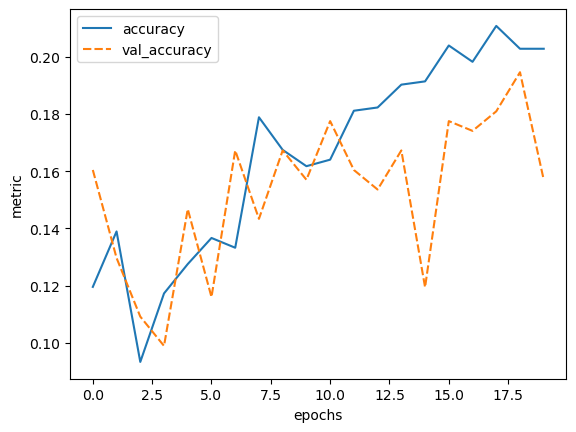

In [19]:
compile_model(dense_model)
history = dense_model.fit(train_images, train_labels, epochs=20,
                    validation_data=(val_images, val_labels))
plot_history(history, ['accuracy', 'val_accuracy'])

In [20]:
inputs = keras.Input(shape=train_images.shape[1:])
x = keras.layers.Conv2D(50, (3, 3), activation='relu')(inputs)
x = keras.layers.MaxPooling2D((2, 2))(x)
x = keras.layers.Conv2D(50, (3, 3), activation='relu')(x)
x = keras.layers.MaxPooling2D((2, 2))(x)
# Add your extra layers here
x = keras.layers.Flatten()(x)
x = keras.layers.Dense(50, activation='relu')(x)
outputs = keras.layers.Dense(10)(x)

In [21]:
def create_nn_extra_layer():
    inputs = keras.Input(shape=train_images.shape[1:])
    x = keras.layers.Conv2D(50, (3, 3), activation='relu')(inputs)
    x = keras.layers.MaxPooling2D((2, 2))(x)
    x = keras.layers.Conv2D(50, (3, 3), activation='relu')(x)
    x = keras.layers.MaxPooling2D((2, 2))(x) #
    x = keras.layers.Conv2D(50, (3, 3), activation='relu')(x) # extra layer
    x = keras.layers.MaxPooling2D((2, 2))(x) # extra layer
    x = keras.layers.Flatten()(x)
    x = keras.layers.Dense(50, activation='relu')(x)
    outputs = keras.layers.Dense(10)(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="dollar_street_model")
    return model

model = create_nn_extra_layer()

In [22]:
model.summary()


Model: "dollar_street_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 62, 62, 50)     │         1,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 31, 31, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 29, 29, 50)     │        22,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 50)     │        22,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 6, 6, 50)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1800)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 50)             │        90,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 137,060 (535.39 KB)

 Trainable params: 137,060 (535.39 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
compile_model(model)
history = model.fit(train_images, train_labels, epochs=5,
                   validation_data=(val_images, val_labels))
plot_history(history, ['accuracy', 'val_accuracy'])

Epoch 1/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 13s 434ms/step - accuracy: 0.1378 - loss: 2.3021 - val_accuracy: 0.1468 - val_loss: 2.2931
Epoch 2/5
12/28 ━━━━━━━━━━━━━━━━━━━━ 14s 927ms/step - accuracy: 0.1549 - loss: 2.2938

In [ ]:
def create_nn_with_dropout():
    inputs = keras.Input(shape=train_images.shape[1:])
    x = keras.layers.Conv2D(50, (3, 3), activation='relu')(inputs)
    x = keras.layers.MaxPooling2D((2, 2))(x)
    x = keras.layers.Dropout(0.8)(x) # This is new!

    x = keras.layers.Conv2D(50, (3, 3), activation='relu')(x)
    x = keras.layers.MaxPooling2D((2, 2))(x)
    x = keras.layers.Dropout(0.8)(x) # This is new!

    x = keras.layers.Conv2D(50, (3, 3), activation='relu')(x)
    x = keras.layers.MaxPooling2D((2, 2))(x)
    x = keras.layers.Dropout(0.8)(x) # This is new!

    x = keras.layers.Flatten()(x)
    x = keras.layers.Dense(50, activation='relu')(x)
    outputs = keras.layers.Dense(10)(x)
    model = keras.Model(inputs=inputs, outputs=outputs, name="dropout_model")
    return model

model_dropout = create_nn_with_dropout()
model_dropout.summary()

In [ ]:
plot_history(history, ['accuracy', 'val_accuracy'])

In [ ]:
def create_nn_with_dropout(dropout_rate):
    inputs = keras.Input(shape=train_images.shape[1:])
    x = keras.layers.Conv2D(50, (3, 3), activation='relu')(inputs)
    x = keras.layers.MaxPooling2D((2, 2))(x)
    x = keras.layers.Dropout(dropout_rate)(x)

    x = keras.layers.Conv2D(50, (3, 3), activation='relu')(x)
    x = keras.layers.MaxPooling2D((2, 2))(x)
    x = keras.layers.Dropout(dropout_rate)(x)

    x = keras.layers.Conv2D(50, (3, 3), activation='relu')(x)
    x = keras.layers.Dropout(dropout_rate)(x)
    x = keras.layers.Flatten()(x)
    x = keras.layers.Dense(50, activation='relu')(x)
    outputs = keras.layers.Dense(10)(x)
    model = keras.Model(inputs=inputs, outputs=outputs, name="dropout_model")
    return model

early_stopper = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

dropout_rates = [0.2, 0.4, 0.6, 0.8, 0.9, 0.95]
val_losses = []
for dropout_rate in dropout_rates:
    model_dropout = create_nn_with_dropout(dropout_rate)
    compile_model(model_dropout)
    model_dropout.fit(train_images, train_labels, epochs=30,
                      validation_data=(val_images, val_labels),
                      callbacks=[early_stopper]
                      )

    val_loss, val_acc = model_dropout.evaluate(val_images,  val_labels)
    val_losses.append(val_loss)

loss_df = pd.DataFrame({'dropout_rate': dropout_rates, 'val_loss': val_losses})


sns.lineplot(data=loss_df, x='dropout_rate', y='val_loss')

In [ ]:
def create_nn_with_hp(dropout_rate, n_layers):
    inputs = keras.Input(shape=train_images.shape[1:])
    x = inputs
    for layer in range(n_layers):
        x = keras.layers.Conv2D(50, (3, 3), activation='relu')(x)
        x = keras.layers.MaxPooling2D((2, 2))(x)
    x = keras.layers.Dropout(dropout_rate)(x)
    x = keras.layers.Flatten()(x)
    x = keras.layers.Dense(50, activation='relu')(x)
    outputs = keras.layers.Dense(10)(x)
    model = keras.Model(inputs=inputs, outputs=outputs, name="cifar_model")
    return model

In [ ]:
!pip install keras_tuner

In [ ]:
import keras_tuner

hp = keras_tuner.HyperParameters()

def build_model(hp):
    # Define values for hyperparameters to try out:
    n_layers = hp.Int("n_layers", min_value=1, max_value=2, step=1)
    dropout_rate = hp.Float("dropout_rate", min_value=0.2, max_value=0.8, step=0.3)

    model = create_nn_with_hp(dropout_rate, n_layers)
    compile_model(model)
    return model

tuner = keras_tuner.GridSearch(build_model, objective='val_loss')

tuner.search(train_images, train_labels, epochs=20,
             validation_data=(val_images, val_labels))

In [ ]:
tuner.results_summary()


In [ ]:
def create_nn_with_hp(activation_function, kernel_size):
    inputs = keras.Input(shape=train_images.shape[1:])
    x = inputs
    for layer in range(3):
        x = keras.layers.Conv2D(50, (kernel_size, kernel_size), activation=activation_function)(x)
        x = keras.layers.MaxPooling2D((2, 2))(x)
    x = keras.layers.Dropout(0.2)(x)
    x = keras.layers.Flatten()(x)
    x = keras.layers.Dense(50, activation=activation_function)(x)
    outputs = keras.layers.Dense(10)(x)
    model = keras.Model(inputs=inputs, outputs=outputs, name="cifar_model")
    return model

hp = keras_tuner.HyperParameters()

def build_model(hp):
    kernel_size = hp.Int("kernel_size", min_value=3, max_value=4, step=1)
    activation = hp.Choice("activation", ["relu", "tanh"])
    model = create_nn_with_hp(activation, kernel_size)
    compile_model(model)
    return model

tuner = keras_tuner.GridSearch(build_model, objective='val_loss', project_name='new_project')
tuner.search(train_images, train_labels, epochs=20,
             validation_data=(val_images, val_labels))

In [ ]:
tuner.results_summary()

In [ ]:
#model.save('cnn_model.keras')